In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
from typing import TypedDict,Annotated,Literal,Optional,List
from dotenv import load_dotenv

from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import BaseMessage,HumanMessage,AIMessage,SystemMessage

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings

from langchain_core.tools import tool
from langgraph.prebuilt import  ToolNode, tools_condition

import uuid
import os

c:\Users\adiko\OneDrive\Desktop\router+hitl(chatbot)\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
memory = MemorySaver()

In [4]:
model= ChatOpenAI(
    model="arcee-ai/trinity-large-preview:free",
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url=os.getenv("OPENAI_BASE_URL"),
    temperature=0.3
)

In [5]:
class AgentState(TypedDict):
    query: str
    intent: Optional[Literal["billing", "tech", "general"]]
    response: Optional[str]

    email_required: Optional[bool]
    draft_version: int

    escalate: Optional[bool]
    
    email_draft: Optional[str]
    review_status: Optional[Literal["approved", "revise"]]
  
    feedback_history: List[str]
    messages: List[BaseMessage] 

In [6]:
class RouterOutput(BaseModel):
    intent: Literal["billing", "tech", "general"]

In [7]:
router_llm = model.with_structured_output(RouterOutput)

def router_node(state: AgentState):

    query = state["query"]
    messages = state.get("messages", [])
    messages.append(HumanMessage(content=query))
    prompt = f"""
    You are a support query classifier for a HOSPITAL billing system.

    Classify the user's query into ONE of these categories:

    billing → ANY question about charges, fees, costs, rates, payments, 
            refunds, invoices, advances, registration fees, OPD charges,
            room tariffs, doctor fees, or any hospital pricing/billing topic

    tech    → login issues, bugs, app/portal errors, system problems

    general → anything NOT related to billing or technical issues

    Return only one category.

    Query:
    {query}
    """
    result = router_llm.invoke(prompt)

    return {"intent": result.intent,
            "messages": messages}


In [8]:
class BillingOutput(BaseModel):
    response: str
    email_required: bool

In [9]:
loader = PyPDFLoader('max_hospital.pdf')
docs= loader.load()
len(docs)

13

In [10]:
spitter= RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks=spitter.split_documents(docs)
embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
vector_store=FAISS.from_documents(chunks,embedding)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4454.99it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
retriever= vector_store.as_retriever(search_type='similarity',search_kwargs={'k':5})

In [12]:
@tool
def rag_tool(query: str) -> dict:
    """Retrive relevant billing information from the pdf document .
     Use this tool when the user asks billing related policy questions
    like refund, subscription, invoice, or payment failure that may
    be answered from the stored documents."""

    result= retriever.invoke(query)
    context = "\n\n".join([doc.page_content for doc in result])
    metadata=[doc.metadata for doc in result]

    return{
        'query':query,
        'context': context,
        'metadata':metadata
    }

In [13]:
tools=[rag_tool]

In [14]:
tool_bill_llm = model.bind_tools(tools)

def billing_query_node(state: AgentState):

    query = state["query"]
    messages = state.get("messages", [])

    prompt = f"""
You are a billing support assistant.

If the user asks about billing policies like refund, payment failure,
subscription rules, invoices etc, you MUST use the rag_tool to retrieve
relevant information from the billing documents.

If the issue requires manual intervention (duplicate charge, refund processing,
account correction, or investigation), clearly state that the issue requires
ESCALATION.

IMPORTANT:
When escalation is required only then, include one of the following phrases in your response:
- escalate to billing team
- manual review required
- duplicate charge investigation required
- investigation required by billing team

These phrases help the system trigger escalation.

Customer Query:
{query}
"""

    llm_input = [SystemMessage(content=prompt)] + messages
    result = tool_bill_llm.invoke(llm_input)

    # ✅ FIX 1: Handle content being a list (multimodal) vs string
    if isinstance(result.content, list):
        response_text = " ".join(
            block.get("text", "") for block in result.content
            if isinstance(block, dict)
        )
    else:
        response_text = result.content or ""

    # ✅ FIX 2: Only append AIMessage if there's actual content
    # (avoid polluting message history with empty tool-call messages)
    if response_text.strip():
        messages.append(AIMessage(content=response_text))
    else:
        # Still append the message (it has tool_calls), needed by ToolNode
        messages.append(result)

    # ✅ FIX 3: Preserve previous non-empty response if this pass is empty
    # (happens on first pass when LLM is calling a tool, not yet answering)
    previous_response = state.get("response") or ""
    final_response = response_text.strip() if response_text.strip() else previous_response

    # ✅ FIX 4: Fallback if model gives empty final response
    if not final_response and not result.tool_calls:
        final_response = (
            "I was unable to retrieve a specific answer. "
            "Please contact our billing support team directly for assistance."
        )

    escalation_keywords = [
        "escalate",
        "billing team",
        "manual review",
        "duplicate charge",
        "investigation required"
    ]
    email_required = any(
        word in final_response.lower() for word in escalation_keywords
    )

    return {
        "response": final_response,
        "email_required": email_required,
        "messages": messages
    }

In [15]:
def billing_email_router1(state: AgentState):

    if state.get("email_required"):
        return "human_escalation"

    return "__end__"

In [16]:
def billing_email_router_node(state: AgentState):
    return {}

In [17]:
def human_escalation_node(state: AgentState):

    print("\nCustomer query requires escalation to billing.\n")
    print("User query:", state["query"])
    print("System response:", state["response"])

    decision = input("\nDo you want to escalate to billing email? (yes/no): ")

    if decision.lower() == "yes":
        return {"escalate": True}

    return {"escalate": False}

In [18]:
def escalation_router(state: AgentState):

    if state.get("escalate"):
        return "draft"

    return "__end__"

In [19]:
def draft_email_node(state: AgentState):

    query = state["query"]
    response = state["response"]
    feedback_history = state.get("feedback_history", [])
    previous_draft = state.get("email_draft")
    version = state.get("draft_version", 0) + 1
    messages = state.get("messages", [])
    if previous_draft :
        feedback_text = "\n".join(
            [f"{i+1}. {f}" for i,f in enumerate(feedback_history)]
        )
        prompt = f"""
    You previously wrote the following email:

    {previous_draft}

    Reviewer feedback:
    {feedback_text}

    Rewrite the email according to the feedback.

    IMPORTANT GUIDELINES:
    - Keep the same email structure
    - Do NOT remove important information
    - Adjust wording and tone based on the feedback
    - Do NOT summarize
    - Do NOT use "..."

    Tone guidance:
    If the feedback mentions tone (friendly, empathetic, apologetic, professional),
    modify the wording while keeping the content intact.

    EMAIL FORMAT:

    Subject: <summary>

    Dear Billing Team,

    <Customer issue explanation>

    Relevant Details:
    - Customer Query: {query}
    - System Response: {response}

    Requested Action:
    <what billing team should check>

    Thank you for your assistance.

    Best regards,
    Customer Support Assistant
    """
    else:
        prompt = f"""
    Write a professional email to the billing team.

    Follow this exact format:

    Subject: <summary>

    Dear Billing Team,

    <Customer issue explanation>

    Relevant Details:
    - Customer Query: {query}
    - System Response: {response}

    Requested Action:
    <what billing team should check>

    Thank you for your assistance.

    Best regards,
    Customer Support Assistant
    """

    result = model.invoke(prompt)
    messages.append(AIMessage(content=result.content))
    return {
    "email_draft": result.content,
    "draft_version": version,
    "messages": messages
}

In [20]:
def review_node(state: AgentState):

    version = state.get("draft_version", 1)

    print(f"\n------ EMAIL DRAFT v{version} ------\n")
    print(state["email_draft"])

    decision = input("\nApprove email? (approve / revise): ")

    if decision == "approve":
        return {"review_status": "approved"}

    feedback = input("Enter feedback for revision: ")
    history = state.get("feedback_history", [])
    history.append(feedback)

    return {
        "review_status": "revise",
        "feedback_history": history
    }

In [21]:
def review_router(state: AgentState):

    if state["review_status"] == "approved":
        return "send"

    return "draft"

In [22]:
def send_email_node(state: AgentState):

    print("\nSending email to xyz@company.com...\n")

    print(state["email_draft"])

    print("\nEmail sent successfully.")

    return {}

In [23]:
def route_intent(state: AgentState):

    return state["intent"]

In [24]:
tool_node=ToolNode(tools)

In [25]:
builder = StateGraph(AgentState)

#NODES
builder.add_node("router", router_node)
builder.add_node("billing_query", billing_query_node)
builder.add_node("billing_tools", tool_node)
builder.add_node("billing_email_router", billing_email_router_node)
builder.add_node("human_escalation", human_escalation_node)
builder.add_node("draft", draft_email_node)
builder.add_node("review", review_node)
builder.add_node("send", send_email_node)

In [26]:
builder.add_edge(START, "router")

In [27]:
builder.add_conditional_edges(
    "router",
    route_intent,
    {
        "billing": "billing_query",
        "tech": END,
        "general": END
    }
)

In [28]:
builder.add_conditional_edges(
    "billing_query",
    tools_condition,
    {
        "tools": "billing_tools",
        "__end__": "billing_email_router"
    }
)

In [29]:
builder.add_conditional_edges(
    "billing_email_router",
    billing_email_router1,
    {
        "human_escalation": "human_escalation",
        "__end__": END
    }
)


In [30]:
builder.add_edge("billing_tools", "billing_query")

In [31]:
builder.add_conditional_edges(
    "human_escalation",
    escalation_router,
    {
        "draft": "draft",
        "__end__": END
    }
)

In [32]:
builder.add_edge("draft", "review")

In [33]:
builder.add_conditional_edges(
    "review",
    review_router,
    {
        "send": "send",
        "draft": "draft"
    }
)

In [34]:
builder.add_edge("send", END)

In [35]:
workflow = builder.compile(checkpointer=memory)

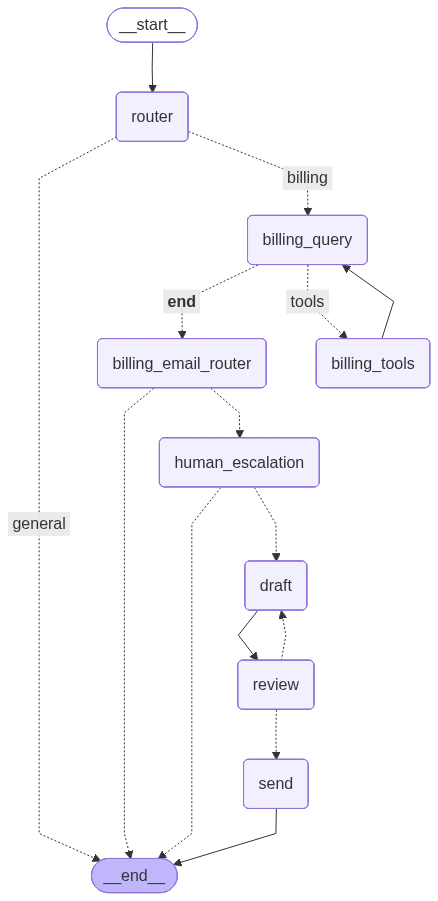

In [36]:
workflow

In [37]:
config = {"configurable": {"thread_id": str(uuid.uuid4())}}


In [39]:
workflow.invoke(
    {
        "query": "I was charged twice for the same procedure. I want a refund immediately.",
        "draft_version": 0,
        "messages": [],
        "feedback_history": []
    },
    config=config
)


Customer query requires escalation to billing.

User query: I was charged twice for the same procedure. I want a refund immediately.
System response: I understand you were charged twice for the same procedure and need a refund. This appears to be a duplicate charge issue that requires manual review and investigation by our billing team.

To process your refund, we'll need to:
1. Verify the duplicate charge
2. Investigate the billing error
3. Process the refund to your original payment method

Please provide:
- The date of the duplicate charge
- The amount charged
- Any confirmation numbers or receipts you have

Once we have this information, we can escalate this to our billing team for investigation and resolution. You should expect to receive your refund within 5-10 business days after the investigation is complete.

Would you like to proceed with this escalation?


{'query': 'I was charged twice for the same procedure. I want a refund immediately.',
 'intent': 'billing',
 'response': "I understand you were charged twice for the same procedure and need a refund. This appears to be a duplicate charge issue that requires manual review and investigation by our billing team.\n\nTo process your refund, we'll need to:\n1. Verify the duplicate charge\n2. Investigate the billing error\n3. Process the refund to your original payment method\n\nPlease provide:\n- The date of the duplicate charge\n- The amount charged\n- Any confirmation numbers or receipts you have\n\nOnce we have this information, we can escalate this to our billing team for investigation and resolution. You should expect to receive your refund within 5-10 business days after the investigation is complete.\n\nWould you like to proceed with this escalation?",
 'email_required': True,
 'draft_version': 0,
 'escalate': False,
 'feedback_history': [],
 'messages': [HumanMessage(content='I was c